# Google Stock Price Prediction using LSTM

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

This notebook demonstrates how to build and train a Long Short-Term Memory (LSTM) recurrent neural network (RNN) to predict Google's stock price based on historical data.

**Dataset:** `google_stock_price_full.csv`

**Goal:** Predict the 'Close' price.

**Training Data:** Before 2024-01-01

**Testing Data:** 2024-01-01 to 2024-04-04

**Steps:**
1. Import Libraries
2. Load and Prepare Data
3. Build the LSTM Model
4. Train the Model
5. Evaluate the Model and Visualize Results

## 1. Import Libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error , r2_score
import math
import os
import joblib # For saving/loading the scaler

## 2. Load and Prepare Data

In [15]:
# Define file paths and parameters
csv_file_path = '/content/drive/MyDrive/Colab Notebooks/stock-prediction/Dataset/google_stock_price_full.csv'
preprocessed_dir = '/content/drive/MyDrive/Colab Notebooks/stock-prediction/preprocessed_data'
scaler_path = os.path.join(preprocessed_dir, 'scaler.gz')
x_train_path = os.path.join(preprocessed_dir, 'x_train.npy')
y_train_path = os.path.join(preprocessed_dir, 'y_train.npy')
x_test_path = os.path.join(preprocessed_dir, 'x_test.npy')
y_test_actual_path = os.path.join(preprocessed_dir, 'y_test_actual.npy')
sequence_length = 60
split_date_str = '2024-01-01'

# Create output directory if it doesn't exist
os.makedirs(preprocessed_dir, exist_ok=True)

# Load the dataset
try:
    df = pd.read_csv(csv_file_path)
except FileNotFoundError:
    print(f'Error: {csv_file_path} not found. Please upload the file to your Colab environment.')
    raise # Stop execution if file is not found

# Convert 'Date' column to datetime objects and set as index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# Use only the 'Close' price for prediction
data = df.filter(['Close'])
dataset = data.values # This is the full dataset of close prices

# Define the split date and find the split index
split_date = pd.to_datetime(split_date_str)
training_data_len = df[df.index < split_date].shape[0]

print(f'Total data points: {len(dataset)}')
print(f'Training data points: {training_data_len}')
print(f'Test data points: {len(dataset) - training_data_len}')

# Scale the data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler ONLY on the training data
scaled_training_data_for_fit = dataset[:training_data_len]
scaler.fit(scaled_training_data_for_fit)

# Scale the entire dataset using the fitted scaler
scaled_data = scaler.transform(dataset)

# Create the training data set (scaled)
train_data_scaled = scaled_data[0:int(training_data_len), :]

# Split the scaled training data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(sequence_length, len(train_data_scaled)):
    x_train.append(train_data_scaled[i-sequence_length:i, 0])
    y_train.append(train_data_scaled[i, 0])

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data to be 3-dimensional [samples, time steps, features] for LSTM input
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Create the testing data set
# Get the required portion of the scaled dataset for creating test sequences
test_data_scaled = scaled_data[training_data_len - sequence_length:, :]

# Create the x_test sequences
x_test = []
for i in range(sequence_length, len(test_data_scaled)):
    x_test.append(test_data_scaled[i-sequence_length:i, 0])

# Convert the x_test data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the actual 'Close' prices for the test period (unscaled) - these are the y_test values
y_test_actual = dataset[training_data_len:, :]

print(f'x_train shape: {x_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'x_test shape: {x_test.shape}')
print(f'y_test_actual shape: {y_test_actual.shape}')

# Save the preprocessed data and the scaler
np.save(x_train_path, x_train)
np.save(y_train_path, y_train)
np.save(x_test_path, x_test)
np.save(y_test_actual_path, y_test_actual)
joblib.dump(scaler, scaler_path)

print(f'Preprocessing complete. Data prepared for model training and testing.')

Total data points: 4940
Training data points: 4875
Test data points: 65
x_train shape: (4815, 60, 1)
y_train shape: (4815,)
x_test shape: (65, 60, 1)
y_test_actual shape: (65, 1)
Preprocessing complete. Data prepared for model training and testing.


## 3. Build the LSTM Model

In [6]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

# Build the LSTM model architecture
model = Sequential()
# First bidirectional LSTM layer with 128 units and return sequences for next LSTM layer
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(x_train.shape[1], 1)))
# Add dropout regularization to prevent overfitting
model.add(Dropout(0.1))
# Second bidirectional LSTM layer with 64 units
model.add(Bidirectional(LSTM(64)))
# Final output layer with single neuron for regression prediction
model.add(Dense(1))

# Compile model with low learning rate Adam optimizer
optimizer = Adam(learning_rate=0.0001)  # Using small learning rate for better convergence
model.compile(optimizer=optimizer, loss='mse')  # Mean Squared Error loss for regression task

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 4. Train the Model

In [7]:
from keras.models import load_model
from keras.callbacks import EarlyStopping

# Model save path (must match your previous save path)
model_save_path = '/content/drive/MyDrive/Colab Notebooks/stock-prediction/trained_google_stock_lstm_model.keras'

try:
    # Attempt to load the pre-trained model
    model = load_model(model_save_path)
    print('✅ Successfully loaded pre-trained model')

except:
    print('❌ No pre-trained model found, training a new model')

    # Define your model architecture here (same as original)
    model = Sequential()  # Add your original model architecture

    # Train new model
    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    history = model.fit(
        x_train, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=64,
        callbacks=[early_stop],
        verbose=1
    )

    # Save the new model
    model.save(model_save_path)
    print(f'New model saved to: {model_save_path}')

✅ Successfully loaded pre-trained model


## 5. Evaluate the Model and Visualize Results

In [9]:
# Get predictions
predictions_scaled = model.predict(x_test)
predictions = scaler.inverse_transform(predictions_scaled)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')

mean_y = np.mean(y_test_actual)
relative_accuracy = (1 - (rmse / mean_y)) * 100
print(f'Relative Accuracy: {relative_accuracy:.2f}%')

# Prepare data for plotting
train = data[:training_data_len]
valid = data[training_data_len:].copy() # Use .copy() to avoid SettingWithCopyWarning
valid['Predictions'] = predictions


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
Root Mean Squared Error (RMSE): 4.7789
Relative Accuracy: 96.70%


# Visualize the actual vs predicted prices (Full Range + Test)

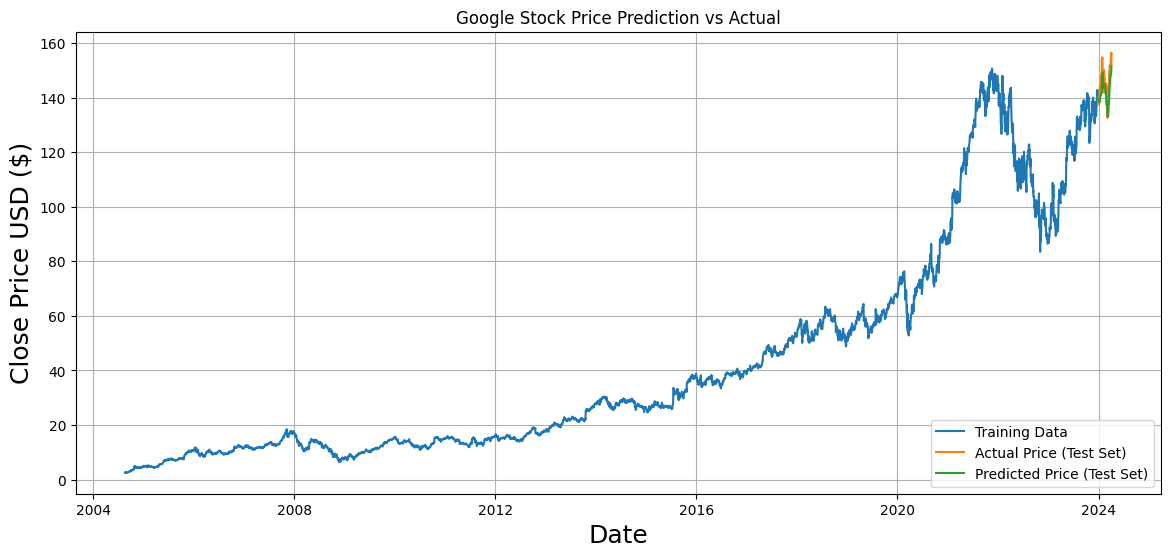

In [10]:
plt.figure(figsize=(14,6))
plt.title('Google Stock Price Prediction vs Actual')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'], label='Training Data')
plt.plot(valid['Close'], label='Actual Price (Test Set)')
plt.plot(valid['Predictions'], label='Predicted Price (Test Set)')
plt.legend(loc='lower right')
plt.grid(True)
#plt.savefig('stock_predictions_vs_actual_full.png') # Save the plot
#print('Saved prediction vs actual plot to stock_predictions_vs_actual_full.png')
plt.show()

# Visualize the actual vs predicted prices (Test Set Only)

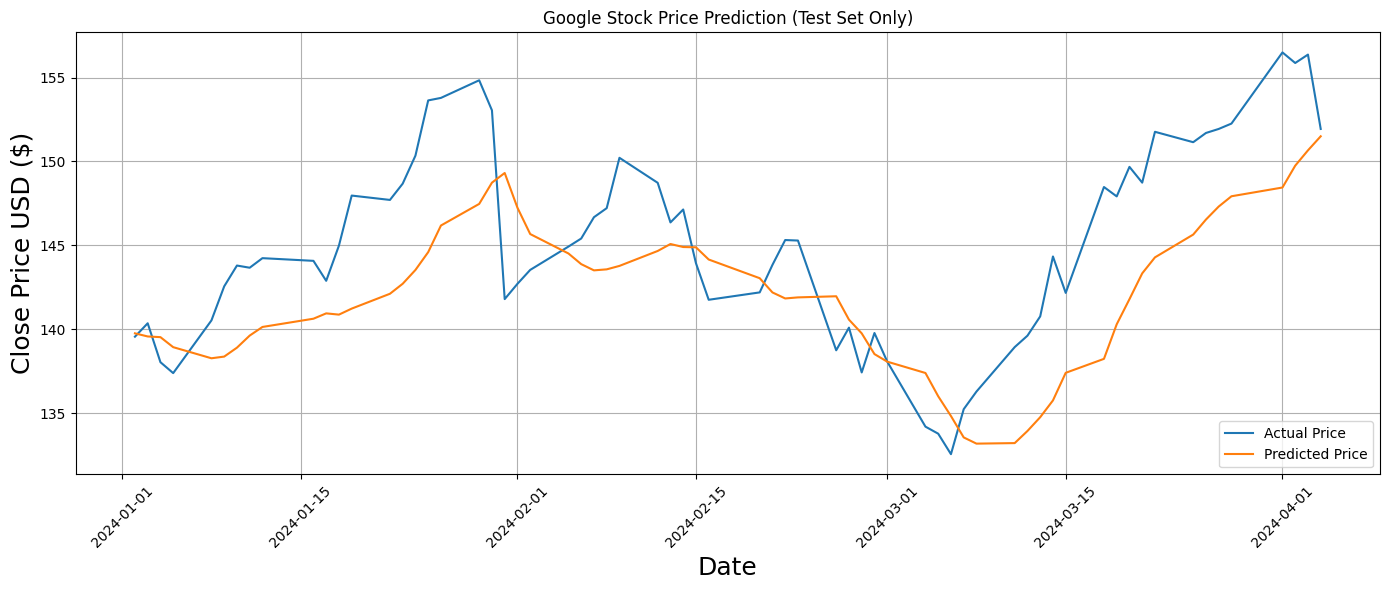

In [11]:
plt.figure(figsize=(14,6))
plt.title('Google Stock Price Prediction (Test Set Only)')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(valid['Close'], label='Actual Price')
plt.plot(valid['Predictions'], label='Predicted Price')
plt.legend(loc='lower right')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('stock_predictions_vs_actual_test.png') # Save the plot
#print('Saved prediction vs actual plot (test set) to stock_predictions_vs_actual_test.png')
plt.show()

# Plot Prediction Errors

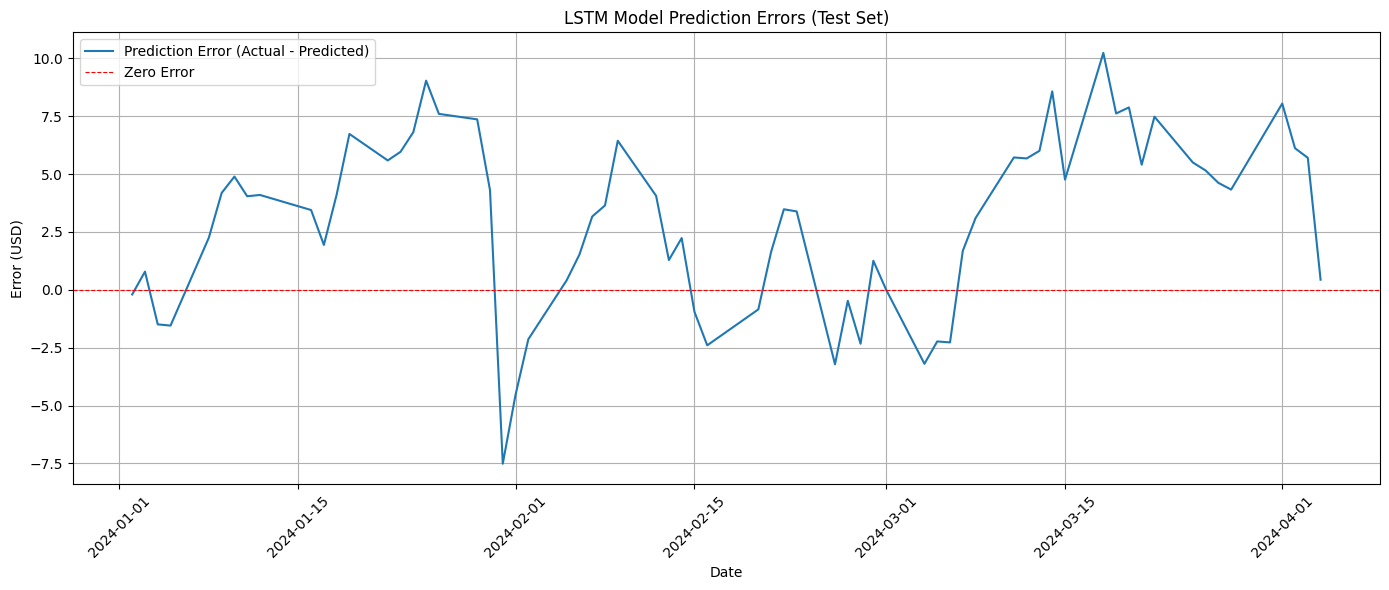

In [12]:
errors = valid['Close'] - valid['Predictions']
plt.figure(figsize=(14, 6))
plt.plot(errors.index, errors, label='Prediction Error (Actual - Predicted)')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8, label='Zero Error')
plt.title('LSTM Model Prediction Errors (Test Set)')
plt.xlabel('Date')
plt.ylabel('Error (USD)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
#plt.savefig('prediction_errors.png') # Save the plot
#print('Saved prediction error plot to prediction_errors.png')
plt.show()

# Save predictions and actual values to a CSV for inspection

In [14]:
results_df = pd.DataFrame({'Actual': y_test_actual.flatten(), 'Predicted': predictions.flatten()}, index=valid.index)
results_df.to_csv('/content/drive/MyDrive/Colab Notebooks/stock-prediction/Dataset/prediction_results.csv')
print('Prediction results saved to prediction_results.csv')

Prediction results saved to prediction_results.csv


In [ ]:

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive
